In [11]:
import pandas as pd
file_path = r"C:\Users\HP\OneDrive\Documents\Retail-Analytics-Customer-Segmentation\data\raw\Online Retail.xlsx"
df = pd.read_excel(file_path)

In [9]:
#show first 5 row
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [17]:
#show last 5 row
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [19]:
# Dataset size
df.shape

(541909, 8)

In [21]:
# Columns name
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [23]:
# show information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [27]:
# Missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [29]:
# duplicate rows
df.duplicated().sum()

5268

In [31]:
# data statistics
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


#### Original data backup

In [35]:
df_clean = df.copy()

In [37]:
print("Original shape :", df_clean.shape)

Original shape : (541909, 8)


### Remove duplicate rows

In [43]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows: 5268
Shape after removing duplicates: (536641, 8)


### Check missing values

In [45]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

### Check data type

In [53]:
df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

### Convert date column

In [55]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
print(df_clean["InvoiceDate"].dtype)

datetime64[ns]


### Create Revenue column

In [57]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### Check invalid quality/price

In [59]:
print("Quantity <= 0:", (df_clean["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df_clean["UnitPrice"] <= 0).sum())

Quantity <= 0: 10587
UnitPrice <= 0: 2512


### Remove invalid quality/price or transaction

In [61]:
# Keep only valid sales transactions
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

print("Shape after removing invalid transactions:", df_clean.shape)

Shape after removing invalid transactions: (524878, 9)


### Recheck validity

In [63]:
print("Quantity <= 0:", (df_clean["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df_clean["UnitPrice"] <= 0).sum())

Quantity <= 0: 0
UnitPrice <= 0: 0


### Recheck missing CustomerID

In [65]:
print("Missing CustomerID:", df_clean["CustomerID"].isnull().sum())
print("Total records:", len(df_clean))

Missing CustomerID: 132186
Total records: 524878


In [67]:
df_final = df_clean.copy()

### Remove missing CustomerID

In [69]:
df_final = df_final.dropna(subset=["CustomerID"]).copy()
print("Shape after removing missing CustomerID:", df_final.shape)

Shape after removing missing CustomerID: (392692, 9)


### Recheck missing CustomerID

In [71]:
print("Missing CustomerID:", df_final["CustomerID"].isnull().sum())

Missing CustomerID: 0


### CustomerID format

In [73]:
df_final["CustomerID"] = df_final["CustomerID"].astype(int)
df_final["CustomerID"].head()

0    17850
1    17850
2    17850
3    17850
4    17850
Name: CustomerID, dtype: int32

### Verify revenue

In [75]:
df_final["Revenue"] = df_final["Quantity"] * df_final["UnitPrice"]
df_final[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### Final dataset check

In [77]:
print("Final Dataset Shape:", df_final.shape)

print("\nMissing Values:")
print(df_final.isnull().sum())

print("\nDuplicate Rows:")
print(df_final.duplicated().sum())

Final Dataset Shape: (392692, 9)

Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

Duplicate Rows:
0


### Total Revenue

In [100]:
total_revenue = df_final["Revenue"].sum()
print("Total Revenue : ",total_revenue)

Total Revenue is :  8887208.894


### Total Customer

In [124]:
total_customers = df_final["CustomerID"].nunique()
print("Total Customer : ",total_customers)

Total Customer :  4338


### Total Order

In [126]:
total_orders = df_final["InvoiceNo"].nunique()
print("Total orders : ",total_orders)

Total orders :  18532


### Total Products

In [128]:
total_products = df_final["StockCode"].nunique()
print("Total products : ",total_products)

Total products :  3665


### Countries

In [117]:
total_countries = df_final["Country"].nunique()
print("Total countries : ",total_countries)

Total countries :  37


### Average Order Value

In [132]:
avg_order_value = total_revenue / total_orders
print("The average order value : ",avg_order_value)

The average order value :  479.56016047917115


In [134]:
summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Customers",
        "Total Orders",
        "Total Products",
        "Total Countries",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_customers,
        total_orders,
        total_products,
        total_countries,
        avg_order_value
    ]
})

summary

,Metric,Value
0,Total Revenue,8.887209e+06
1,Total Customers,4.338000e+03
2,Total Orders,1.853200e+04
3,Total Products,3.665000e+03
4,Total Countries,3.700000e+01
5,Average Order Value,4.795602e+02


### Monthly Revenue Analysis

In [137]:
monthly_revenue = (
    df_final
    .groupby(df_final["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["InvoiceDate"] = monthly_revenue["InvoiceDate"].astype(str)

monthly_revenue.columns = ["Month", "Revenue"]

monthly_revenue

,Month,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


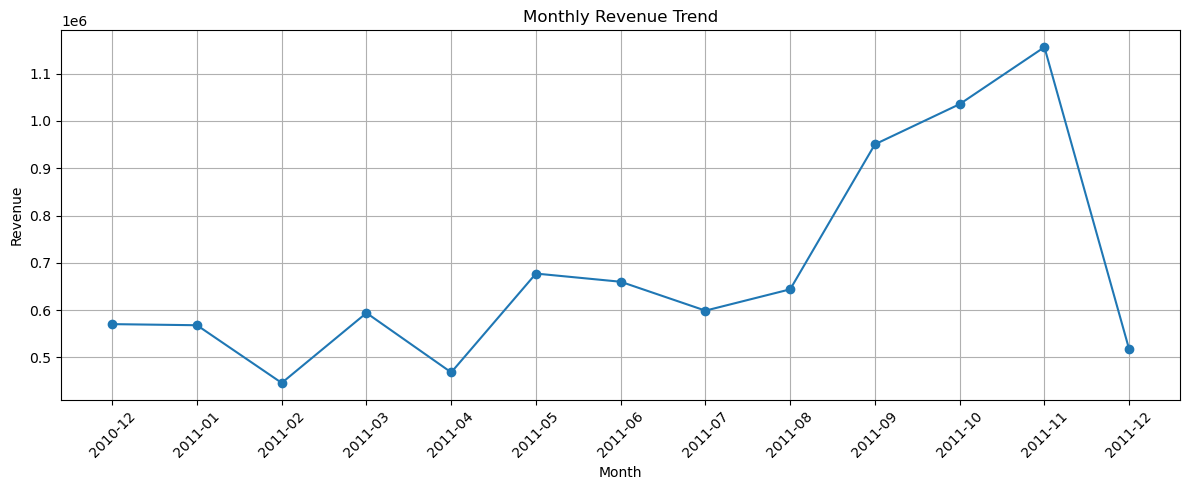

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Top 10 product by revenue

In [142]:
top_products = (
    df_final
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products.columns = ["Product", "Revenue"]

top_products

,Product,Revenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,Manual,53419.93
9,RABBIT NIGHT LIGHT,51251.24


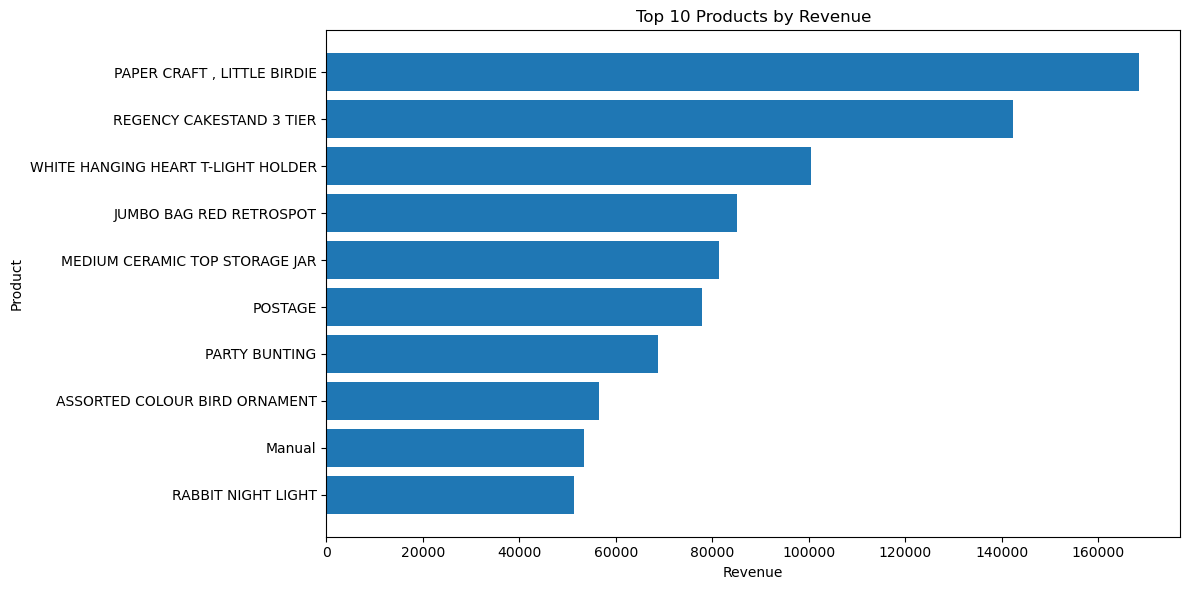

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.barh(
    top_products["Product"],
    top_products["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Country wise revenue analysis

In [149]:
country_revenue = (
    df_final
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
country_revenue.columns = ["Country","Revenue"]
country_revenue

,Country,Revenue
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


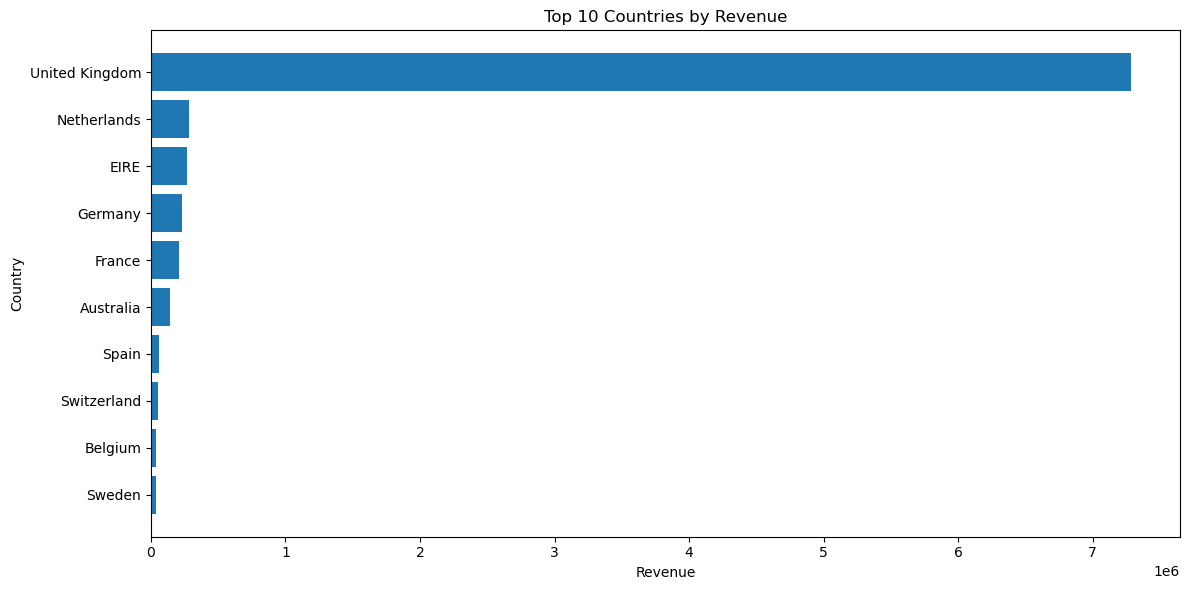

In [151]:
import matplotlib.pyplot as plt

top_countries = country_revenue.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_countries["Country"],
    top_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Customer Purchase Analysis

In [154]:
customer_analysis = (
    df_final
    .groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_analysis.head(10)

,CustomerID,Total_Revenue,Total_Orders,Total_Quantity
0,12346,77183.60,1,74215
1,12347,4310.00,7,2458
2,12348,1797.24,4,2341
3,12349,1757.55,1,631
4,12350,334.40,1,197
5,12352,2506.04,8,536
6,12353,89.00,1,20
7,12354,1079.40,1,530
8,12355,459.40,1,240
9,12356,2811.43,3,1591


In [156]:
# Top 10 Customers by Revenue

top_customers = (
    customer_analysis
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_customers

,CustomerID,Total_Revenue,Total_Orders,Total_Quantity
1689,14646,280206.02,73,196915
4201,18102,259657.30,60,64124
3728,17450,194390.79,46,69973
3008,16446,168472.50,2,80997
1879,14911,143711.17,201,80240
55,12415,124914.53,21,77374
1333,14156,117210.08,55,57768
3771,17511,91062.38,31,64549
2702,16029,80850.84,63,40108
0,12346,77183.60,1,74215


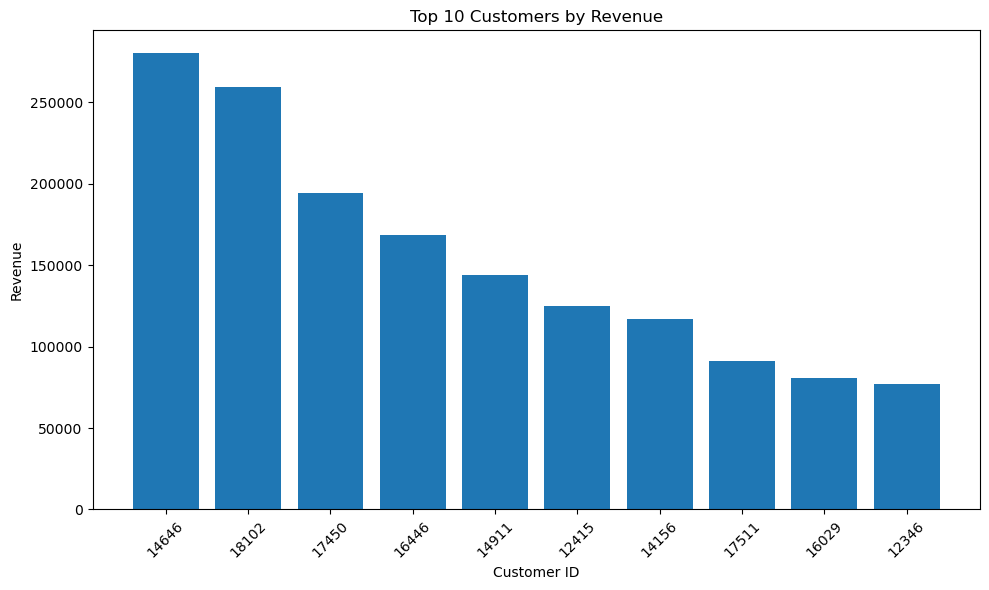

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    top_customers["CustomerID"].astype(str),
    top_customers["Total_Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Customer Order Frequency Analysis

In [161]:
order_frequency = (
    customer_analysis["Total_Orders"]
    .value_counts()
    .sort_index()
)

order_frequency.head(20)

Total_Orders
1     1493
2      835
3      508
4      388
5      242
6      172
7      143
8       98
9       68
10      54
11      52
12      45
13      30
14      20
15      28
16      11
17      18
18      14
19      12
20      12
Name: count, dtype: int64

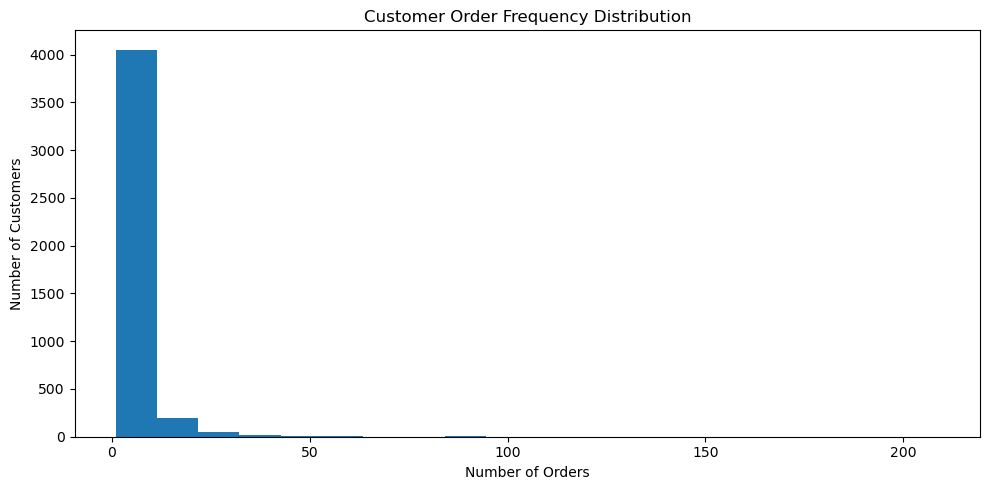

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    customer_analysis["Total_Orders"],
    bins=20
)

plt.title("Customer Order Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [165]:
# Repeat Customer Analysis

repeat_customers = (
    customer_analysis[customer_analysis["Total_Orders"] > 1]
    .shape[0]
)

one_time_customers = (
    customer_analysis[customer_analysis["Total_Orders"] == 1]
    .shape[0]
)

print("One-time Customers:", one_time_customers)
print("Repeat Customers:", repeat_customers)

One-time Customers: 1493
Repeat Customers: 2845


### Quality vs Revenue Analysis

In [168]:
quantity_revenue = (
    df_final
    .groupby("Quantity")["Revenue"]
    .sum()
    .reset_index()
)

quantity_revenue.head(10)

,Quantity,Revenue
0,1,373234.034
1,2,510386.120
2,3,274777.050
3,4,485360.600
4,5,91943.950
5,6,627092.400
6,7,21872.200
7,8,249606.240
8,9,29254.410
9,10,407160.200


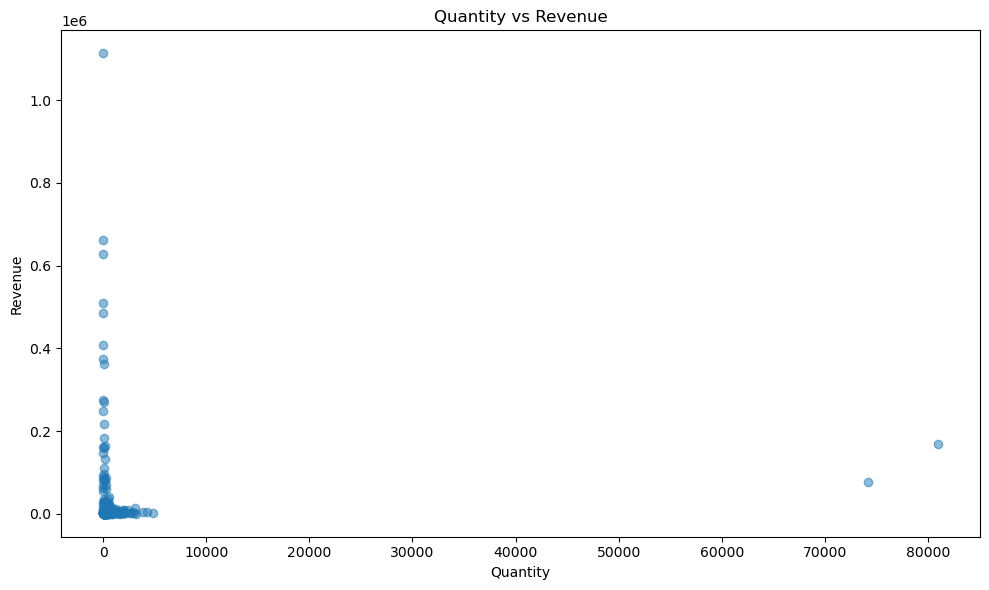

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    quantity_revenue["Quantity"],
    quantity_revenue["Revenue"],
    alpha=0.5
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [172]:
# Top quantities sold in a single transaction

df_final.nlargest(10, "Quantity")[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40


## RFM Analysis

### Reference date

In [175]:
reference_date = df_final["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Latest Invoice Date:", df_final["InvoiceDate"].max())
print("RFM Reference Date:", reference_date)

Latest Invoice Date: 2011-12-09 12:50:00
RFM Reference Date: 2011-12-10 12:50:00


### Calculate RFM Metrics

In [180]:
rfm = (
    df_final
    .groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [182]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### RFM Scoring

In [185]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,326,1,77183.60,1,1,5
1,12347,2,7,4310.00,5,5,5
2,12348,75,4,1797.24,2,4,4
3,12349,19,1,1757.55,4,1,4
4,12350,310,1,334.40,1,1,2
5,12352,36,8,2506.04,3,5,5
6,12353,204,1,89.00,1,1,1
7,12354,232,1,1079.40,1,1,4
8,12355,214,1,459.40,1,1,2
9,12356,23,3,2811.43,4,3,5


In [187]:
# Combined RFM Score

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112
5,12352,36,8,2506.04,3,5,5,355
6,12353,204,1,89.00,1,1,1,111
7,12354,232,1,1079.40,1,1,4,114
8,12355,214,1,459.40,1,1,2,112
9,12356,23,3,2811.43,4,3,5,435


### Customer Segmentation

In [190]:
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "New Customers"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost Customers"

    else:
        return "Potential Loyalists"


rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Potential Loyalists
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,New Customers
4,12350,310,1,334.40,1,1,2,112,Lost Customers
5,12352,36,8,2506.04,3,5,5,355,Loyal Customers
6,12353,204,1,89.00,1,1,1,111,Lost Customers
7,12354,232,1,1079.40,1,1,4,114,Potential Loyalists
8,12355,214,1,459.40,1,1,2,112,Lost Customers
9,12356,23,3,2811.43,4,3,5,435,Loyal Customers


In [192]:
# Customer Segment Distribution

segment_distribution = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = ["Segment", "Customer_Count"]

segment_distribution

,Segment,Customer_Count
0,Potential Loyalists,1024
1,Champions,957
2,Lost Customers,821
3,Loyal Customers,764
4,At Risk,453
5,New Customers,319


In [194]:
# Segment Percentage

segment_distribution["Percentage"] = (
    segment_distribution["Customer_Count"]
    / segment_distribution["Customer_Count"].sum()
    * 100
)

segment_distribution

,Segment,Customer_Count,Percentage
0,Potential Loyalists,1024,23.605348
1,Champions,957,22.060858
2,Lost Customers,821,18.925772
3,Loyal Customers,764,17.611803
4,At Risk,453,10.442600
5,New Customers,319,7.353619


### Customer Segment Visualization

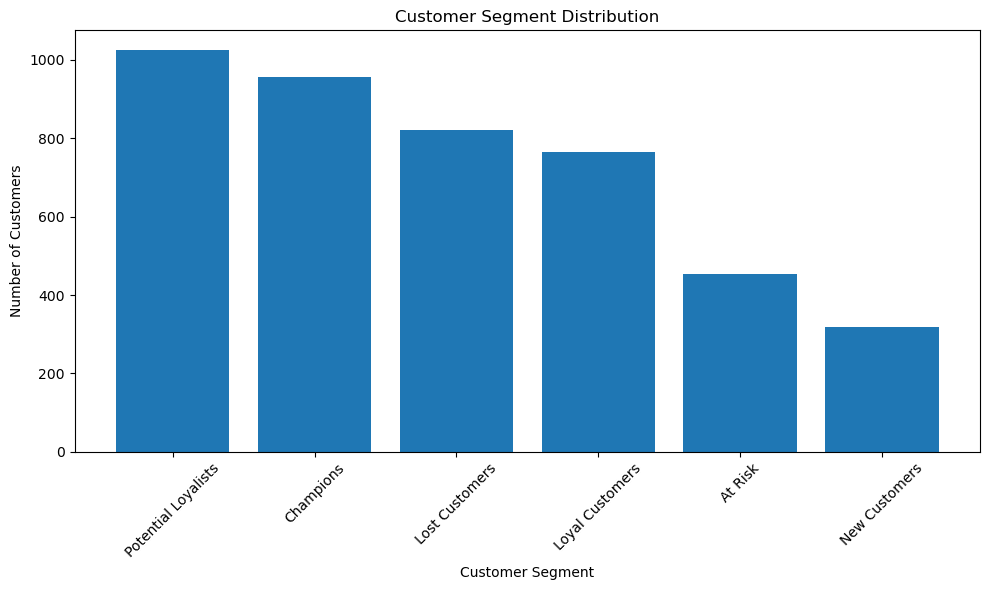

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    segment_distribution["Segment"],
    segment_distribution["Customer_Count"]
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [199]:
# Revenue by Customer Segment

segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue.columns = ["Segment", "Revenue"]

segment_revenue

,Segment,Revenue
0,Champions,5791640.740
1,Loyal Customers,1396513.161
2,At Risk,739477.551
3,Potential Loyalists,626728.211
4,Lost Customers,187629.491
5,New Customers,145219.740


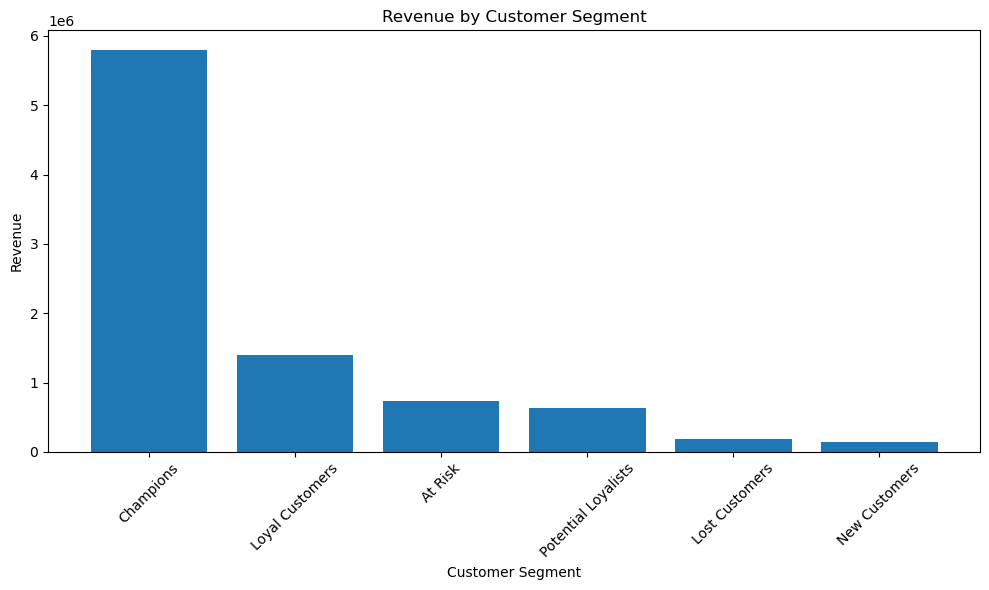

In [201]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue["Segment"],
    segment_revenue["Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Load cleaned dataset to sql express

In [203]:
import pyodbc
print("pyodbc is ready")

pyodbc is ready


In [205]:
import pyodbc

server = r"LAPTOP-GUFC73UJ\SQLEXPRESS"
database = "RetailAnalytics"

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

print("SQL Server connection successful!")

SQL Server connection successful!


In [212]:
print("Connected database:", conn.getinfo(pyodbc.SQL_DATABASE_NAME))
print("Connected server:", conn.getinfo(pyodbc.SQL_SERVER_NAME))

Connected database: RetailAnalytics
Connected server: LAPTOP-GUFC73UJ\SQLEXPRESS


In [214]:
cursor = conn.cursor()

cursor.execute("""
SELECT TABLE_SCHEMA, TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_NAME = 'RetailTransactions'
""")

print(cursor.fetchall())

[]


In [218]:
cursor.execute("""
IF NOT EXISTS (
    SELECT * 
    FROM INFORMATION_SCHEMA.TABLES
    WHERE TABLE_NAME = 'RetailTransactions'
)
BEGIN
    CREATE TABLE dbo.RetailTransactions (
        InvoiceNo VARCHAR(20),
        StockCode VARCHAR(20),
        Description VARCHAR(255),
        Quantity INT,
        InvoiceDate DATETIME,
        UnitPrice DECIMAL(10,2),
        CustomerID INT,
        Country VARCHAR(100),
        Revenue DECIMAL(12,2)
    )
END
""")

conn.commit()

print("RetailTransactions table is ready!")

RetailTransactions table is ready!


In [220]:
cursor.execute("""
SELECT COUNT(*)
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_NAME = 'RetailTransactions'
""")

print("Table exists:", cursor.fetchone()[0])

Table exists: 1


In [222]:
# Load cleaned data into SQL Server

cursor = conn.cursor()
cursor.fast_executemany = True

insert_query = """
INSERT INTO dbo.RetailTransactions
(
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country,
    Revenue
)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
"""

data = list(sql_df.itertuples(index=False, name=None))

print("Rows to insert:", len(data))

cursor.executemany(insert_query, data)
conn.commit()

print("Data loaded successfully!")

Rows to insert: 392692
Data loaded successfully!


In [224]:
cursor = conn.cursor()

cursor.execute("""
SELECT COUNT(*)
FROM dbo.RetailTransactions
""")

row_count = cursor.fetchone()[0]

print("Rows in SQL Server:", row_count)
print("Rows in Python:", len(df_final))

Rows in SQL Server: 392692
Rows in Python: 392692


In [226]:
cursor.execute("""
SELECT TOP 10 *
FROM dbo.RetailTransactions
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

('536365', '85123A', 'WHITE HANGING HEART T-LIGHT HOLDER', 6, datetime.datetime(2010, 12, 1, 8, 26), Decimal('2.55'), 17850, 'United Kingdom', Decimal('15.30'))
('536365', '71053', 'WHITE METAL LANTERN', 6, datetime.datetime(2010, 12, 1, 8, 26), Decimal('3.39'), 17850, 'United Kingdom', Decimal('20.34'))
('536365', '84406B', 'CREAM CUPID HEARTS COAT HANGER', 8, datetime.datetime(2010, 12, 1, 8, 26), Decimal('2.75'), 17850, 'United Kingdom', Decimal('22.00'))
('536365', '84029G', 'KNITTED UNION FLAG HOT WATER BOTTLE', 6, datetime.datetime(2010, 12, 1, 8, 26), Decimal('3.39'), 17850, 'United Kingdom', Decimal('20.34'))
('536365', '84029E', 'RED WOOLLY HOTTIE WHITE HEART.', 6, datetime.datetime(2010, 12, 1, 8, 26), Decimal('3.39'), 17850, 'United Kingdom', Decimal('20.34'))
('536365', '22752', 'SET 7 BABUSHKA NESTING BOXES', 2, datetime.datetime(2010, 12, 1, 8, 26), Decimal('7.65'), 17850, 'United Kingdom', Decimal('15.30'))
('536365', '21730', 'GLASS STAR FROSTED T-LIGHT HOLDER', 6, date